<a href="https://colab.research.google.com/github/gokila-a/snowflake-svm/blob/main/snowflake_svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install snowflake-connector-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 1.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pyopenssl to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.1 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
  Attempting uninstall: pyOpenSSL
    Found e

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import snowflake.connector
conn = snowflake.connector.connect(
    user='GOKILA',
    password= 'Btsarmy0739177',
    account= 'TGULZJN-YG81730',
    database= 'water',
    schema= 'PUBLIC',
    warehouse= 'COMPUTE_WH'
)

In [ ]:
query = "SELECT * from water_potability"
df = pd.read_sql(query,conn)
df

/tmp/ipykernel_1191/2439665821.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,NaN,204.890456,20791.31898,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.05786,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.54173,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.41744,8.059332,356.886136,363.266516,18.436525,100.341674,4.628771,0
4,9.092223,181.101509,17978.98634,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681736,47580.99160,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.80216,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.57822,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.86938,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [ ]:
df.head()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,NaN,204.890456,20791.31898,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.05786,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.54173,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.41744,8.059332,356.886136,363.266516,18.436525,100.341674,4.628771,0
4,9.092223,181.101509,17978.98634,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
df.tail()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
3271,4.668102,193.681736,47580.99160,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.80216,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.57822,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.86938,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1
3275,7.874671,195.102299,17404.17706,7.509306,NaN,327.459761,16.140368,78.698446,2.309149,1


In [ ]:
df.shape

(3276, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PH               2785 non-null   float64
 1   HARDNESS         3276 non-null   float64
 2   SOLIDS           3276 non-null   float64
 3   CHLORAMINES      3276 non-null   float64
 4   SULFATE          2495 non-null   float64
 5   CONDUCTIVITY     3276 non-null   float64
 6   ORGANIC_CARBON   3276 non-null   float64
 7   TRIHALOMETHANES  3114 non-null   float64
 8   TURBIDITY        3276 non-null   float64
 9   POTABILITY       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:
df.describe()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690300,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833605,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762125,8.114887,359.950170,481.792305,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196010,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [ ]:
df.isnull().sum()

,0
PH,491
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,781
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,162
TURBIDITY,0
POTABILITY,0


In [ ]:
from scipy.stats import zscore
z_scores = zscore(df)
df[np.abs(z_scores)>2.5]

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
18,8.975464,279.357167,19460.398130,6.204321,NaN,431.443990,12.888759,63.821237,2.436086,0
29,NaN,148.153061,15193.413470,9.046833,307.011793,563.804743,16.568656,52.676185,6.038185,0
37,5.618064,304.235912,17281.975170,6.101084,NaN,399.471566,12.265002,81.588992,2.896547,0
43,9.920691,202.817483,9973.934059,6.882248,337.350529,333.192470,23.917601,71.833624,4.690707,0
51,7.809632,100.457615,12013.550630,5.212315,247.200826,605.220124,9.611349,66.084174,2.447444,0
...,...,...,...,...,...,...,...,...,...,...
3234,6.603417,190.837308,19468.790100,6.375632,380.731901,456.315460,5.934588,83.559326,4.270817,1
3236,4.767472,256.449917,48007.868130,5.773180,NaN,590.429550,16.541561,44.938586,3.893378,1
3241,6.792655,241.724453,9094.313300,6.435809,338.521176,361.107536,14.502464,45.428097,1.917754,1
3269,11.491011,94.812545,37188.826020,9.263166,258.930600,439.893618,16.172755,41.558501,4.369264,1


In [ ]:
log_transform = np.log1p(df)

print(log_transform.head())

         PH  HARDNESS    SOLIDS  CHLORAMINES   SULFATE  CONDUCTIVITY  \
0       NaN  5.327344  9.942339     2.116281  5.912195      6.337372   
1  1.550978  4.870782  9.832585     2.032775       NaN      6.386686   
2  2.208178  5.417150  9.899005     2.329800       NaN      6.039317   
3  2.231816  5.372373  9.999680     2.203795  5.880215      5.897886   
4  2.311765  5.204564  9.797015     2.021097  5.740229      5.989990   

   ORGANIC_CARBON  TRIHALOMETHANES  TURBIDITY  POTABILITY  
0        2.431838         4.477234   1.377035         0.0  
1        2.783777         4.048808   1.704867         0.0  
2        2.883047         4.210943   1.400181         0.0  
3        2.967154         4.618498   1.727891         0.0  
4        2.530380         3.496447   1.624341         0.0  


In [ ]:
from scipy.stats.mstats import winsorize
numeric_cols=df.select_dtypes(include= np.number).columns
for col in numeric_cols:
  df[col]=winsorize(df[col], limits=[0,0.1])
print(df)

            PH    HARDNESS       SOLIDS  CHLORAMINES     SULFATE  \
0          NaN  204.890456  20791.31898     7.300212  368.516441   
1     3.716080  129.422921  18630.05786     6.635246         NaN   
2     8.099124  224.236259  19909.54173     9.124225         NaN   
3     8.316766  214.373394  22018.41744     8.059332  356.886136   
4     9.092223  181.101509  17978.98634     6.546600  310.135738   
...        ...         ...          ...          ...         ...   
3271  4.668102  193.681736  33820.64576     7.166639  359.948574   
3272  7.808856  193.553212  17329.80216     8.061362         NaN   
3273  9.419510  175.762646  33155.57822     7.350233         NaN   
3274  5.126763  230.603758  11983.86938     6.303357         NaN   
3275  7.874671  195.102299  17404.17706     7.509306         NaN   

      CONDUCTIVITY  ORGANIC_CARBON  TRIHALOMETHANES  TURBIDITY  POTABILITY  
0       533.303221       10.379783        86.990970   2.963135           0  
1       533.303221       15.1

<Axes: >

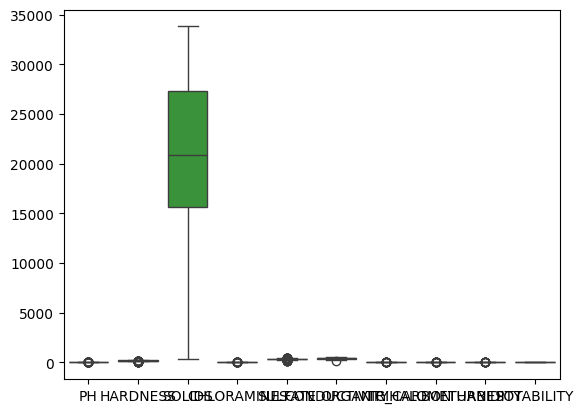

In [ ]:
import seaborn as sns
sns.boxplot(df)


## Data Preprocessing: Handle Missing Values

Before training the SVM model, it's crucial to handle missing values. I will impute the missing values in 'PH', 'SULFATE', and 'TRIHALOMETHANES' columns with their respective means.

In [ ]:
for col in ['PH', 'SULFATE', 'TRIHALOMETHANES']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
PH                 0
HARDNESS           0
SOLIDS             0
CHLORAMINES        0
SULFATE            0
CONDUCTIVITY       0
ORGANIC_CARBON     0
TRIHALOMETHANES    0
TURBIDITY          0
POTABILITY         0
dtype: int64


In [ ]:
# Support Vector Machine (SVM) Implementation
# 1. Defining features (X) and target (y).
# 2. Splitting the data into training and testing sets.
# 3. Training an SVM classifier.
# 4. Making predictions and evaluating the model.

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import StandardScaler

In [ ]:
X = df.drop('POTABILITY', axis=1) # Define features (X) and target (y)
y = df['POTABILITY']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
model = SVC(kernel='linear', random_state=42)

In [ ]:
model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("SVM Model Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", metrics.classification_report(y_test, y_pred))

SVM Model Accuracy: 0.6236012207527976

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.99      0.77       617
           1       0.00      0.00      0.00       366

    accuracy                           0.62       983
   macro avg       0.31      0.50      0.38       983
weighted avg       0.39      0.62      0.48       983



In [ ]:
X_2d = df[['PH', 'HARDNESS']]
y_2d = df['POTABILITY']


In [ ]:
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

In [ ]:
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d_scaled, y_2d, test_size=0.3, random_state=42)

In [ ]:
svm_model_2d = SVC(kernel='linear', random_state=42)
svm_model_2d.fit(X_train_2d, y_train_2d)

SVC(kernel='linear', random_state=42)

In [ ]:
x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

In [ ]:
Z = svm_model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

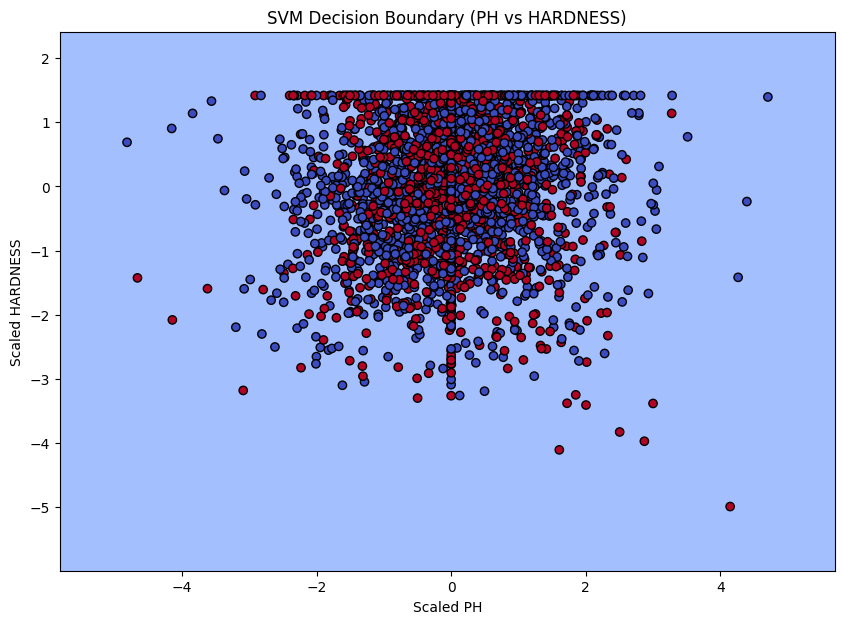

In [ ]:
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
plt.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y_2d, cmap=plt.cm.coolwarm, edgecolors='k')
plt.xlabel('Scaled PH')
plt.ylabel('Scaled HARDNESS')
plt.title('SVM Decision Boundary (PH vs HARDNESS)')
plt.show()